# Incremental Learning + Lightweight/Real-Time Validation

Input: `models/vae_cc1.pt` / `vae_cc1_meta.pkl` / `vae_cc1_eval.pkl` /
`vae_cc1_adaptive_blended_eval.pkl` and `data/processed/{drift_complex_case2}.csv`
+ `data/processed/windows_cc1/*_drift_cc2.npy`.

**Why this notebook exists — closing the two real gaps against the proposal:**

1. **"Lightweight ... real-time deployable"** was asserted throughout the project
   but never measured. Step 1 below measures it directly: parameter count,
   per-window inference latency, model file size.
2. **"Online incremental learning via small SGD updates"** + **"error distribution
   monitoring to detect concept drift"** were the two proposal items with zero
   implementation (the KS-test existed as a one-shot offline check; nothing
   triggered a model update from it). The proposal lists these as connected
   mechanisms, so this notebook wires them together: stream `drift_cc2`
   chronologically, keep the validated blended adaptive threshold running for
   anomaly *decisions*, and periodically run the KS-test against the CC1-train
   baseline — if it signals real drift, trigger a small SGD fine-tune on a
   self-selected buffer of recent likely-normal windows.

**Design discipline, same as the rest of the pipeline:**
- The mechanism itself never sees true labels — only reconstruction error and
  its own threshold's predictions decide what counts as "likely normal" for
  fine-tuning (self-training, same principle as the adaptive-threshold buffer).
- True labels are used **only** in the final evaluation, never fed into the
  running mechanism — no leakage.
- Runs the **exact same chronological stream twice** — once with incremental
  learning OFF (control, identical to what `adaptive_threshold_blended.ipynb`
  already validated) and once ON (treatment) — so any difference in the final
  metrics is attributable to the incremental updates alone.

**What to look for when you run this and send me the output:**
- Step 1's numbers (parameter count / latency / file size) — just report them.
- Step 6's control-vs-treatment table — does F1 improve with incremental
  learning ON? By how much? Does it help most where `drift_cc2`'s oracle-ceiling
  analysis already predicted the most headroom?
- Whether any fine-tune event actually fired (`n_finetunes` printed in Step 4) —
  if zero, the KS-test threshold or `REFIT_INTERVAL` may need adjusting.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pickle, joblib, os, time, copy
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from collections import deque

BASE      = r'c:\Users\jthar\Documents\Claude\Projects\module3\module3'
DATA_DIR  = os.path.join(BASE, 'data', 'processed')
WIN_DIR   = os.path.join(BASE, 'data', 'processed', 'windows_cc1')
MODEL_DIR = os.path.join(BASE, 'models')

WINDOW_SIZE = 30

# Thresholding (reused from adaptive_threshold_blended.ipynb, already validated)
K_ADAPTIVE     = 3.0
BUFFER_SIZE    = 500
PRIOR_STRENGTH = 500

# Incremental learning
REFIT_INTERVAL   = 5000     # check for drift + possibly fine-tune every N windows (global chronological order)
FT_BUFFER_SIZE   = 2000     # pooled (cross-container) recent likely-normal windows available for fine-tuning
FT_LR            = 1e-4     # small SGD learning rate — 10x smaller than the 1e-3 used in original training
FT_EPOCHS        = 5        # a few epochs per fine-tune event, not full retraining
KS_ALPHA         = 0.001    # same significance threshold used in vae_eval.ipynb's drift characterization

print('Paths and constants configured.')

Paths and constants configured.


## Step 1 — Validate "lightweight" and "real-time deployable"

Cheap to measure, never measured before in this project. Parameter count, a
timed forward pass (single window and batched), and on-disk model size.

In [2]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, hidden1), nn.ReLU(), nn.Linear(hidden1, hidden2), nn.ReLU())
        self.fc_mu = nn.Linear(hidden2, latent_dim)
        self.fc_lv = nn.Linear(hidden2, latent_dim)
        self.decoder = nn.Sequential(nn.Linear(latent_dim, hidden2), nn.ReLU(), nn.Linear(hidden2, hidden1), nn.ReLU(), nn.Linear(hidden1, input_dim))
    def encode(self, x):
        h = self.encoder(x); return self.fc_mu(h), torch.clamp(self.fc_lv(h), -10, 10)
    def decode(self, z): return self.decoder(z)
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar); return mu + torch.randn_like(std) * std
    def forward(self, x):
        mu, logvar = self.encode(x); z = self.reparameterize(mu, logvar); return self.decode(z), mu, logvar
    @torch.no_grad()
    def anomaly_score(self, x):
        self.eval(); mu, _ = self.encode(x); return ((self.decode(mu) - x) ** 2).mean(dim=1)

meta          = pickle.load(open(os.path.join(MODEL_DIR, 'vae_cc1_meta.pkl'), 'rb'))
static_eval   = pickle.load(open(os.path.join(MODEL_DIR, 'vae_cc1_eval.pkl'), 'rb'))
CLIP          = meta['clip']
GLOBAL_MEAN   = meta['mu_train']
GLOBAL_STD    = meta['sigma_train']
STATIC_FALLBACK = static_eval['thresholds']['val_p99']

model_path = os.path.join(MODEL_DIR, 'vae_cc1.pt')
n_params = sum(p.numel() for p in VAE(meta['input_dim'], meta['hidden1'], meta['hidden2'], meta['latent_dim']).parameters())
file_size_kb = os.path.getsize(model_path) / 1024

base_model = VAE(meta['input_dim'], meta['hidden1'], meta['hidden2'], meta['latent_dim'])
base_model.load_state_dict(torch.load(model_path, map_location='cpu'))
base_model.eval()

# Single-window latency (the real deployment unit: one window's worth of already-PCA'd features)
x_single = torch.randn(1, meta['input_dim'])
N_TIMING = 2000
with torch.no_grad():
    t0 = time.perf_counter()
    for _ in range(N_TIMING):
        _ = base_model.anomaly_score(x_single)
    t1 = time.perf_counter()
single_latency_ms = (t1 - t0) / N_TIMING * 1000

# Batched latency (1000 windows at once, e.g. a burst of containers reporting together)
x_batch = torch.randn(1000, meta['input_dim'])
with torch.no_grad():
    t0 = time.perf_counter()
    _ = base_model.anomaly_score(x_batch)
    t1 = time.perf_counter()
batch_latency_ms = (t1 - t0) * 1000

print(f'Parameters:              {n_params:,}')
print(f'Model file size:         {file_size_kb:.1f} KB')
print(f'Single-window latency:   {single_latency_ms:.4f} ms  (CPU, no GPU)')
print(f'1000-window batch:       {batch_latency_ms:.2f} ms total ({batch_latency_ms/1000:.4f} ms/window)')
print(f'Theoretical throughput:  {1000/single_latency_ms:.0f} windows/sec (single-window calls, CPU)')

# Fixed historical baseline for the KS-test used later (Step 3/4) — computed ONCE with the
# ORIGINAL, never-fine-tuned model, exactly like vae_eval.ipynb's drift characterization.
# Must stay fixed for the whole run: comparing against a baseline that itself shifts as the
# model gets fine-tuned would be circular and would defeat the point of a "historical" reference.
X_cc1_train = np.clip(np.load(os.path.join(WIN_DIR, 'X_cc1_train.npy')), -CLIP, CLIP).astype(np.float32)
rng = np.random.default_rng(42)
REF_SAMPLE = X_cc1_train[rng.choice(len(X_cc1_train), size=5000, replace=False)]
with torch.no_grad():
    REFERENCE_MSE = base_model.anomaly_score(torch.from_numpy(REF_SAMPLE)).numpy()
print(f'\nFixed KS-test reference: {len(REFERENCE_MSE):,} cc1_train windows, scored with the original (frozen) model.')

Parameters:              10,778
Model file size:         46.7 KB
Single-window latency:   0.4525 ms  (CPU, no GPU)
1000-window batch:       5.64 ms total (0.0056 ms/window)
Theoretical throughput:  2210 windows/sec (single-window calls, CPU)

Fixed KS-test reference: 5,000 cc1_train windows, scored with the original (frozen) model.


## Step 2 — Load `drift_cc2` in true global chronological order

Unlike the per-container threshold buffers (which stay per-container — different
containers have different baselines), the **model itself is shared across all
27 containers**, so incremental fine-tuning should pool recent data across
containers in true wall-clock order, not container-by-container blocks.

In [3]:
def window_meta_with_features(df, feature_cols, window_size=WINDOW_SIZE, stride=1):
    """Rebuilds windows AND their end-timestamp/cmdb_id, matching windowing_pca.ipynb's
    construction exactly (verified below against the saved X/y arrays)."""
    X, cmdb_ids, end_ts, ys, fts = [], [], [], [], []
    for cmdb_id, g in df.sort_values('timestamp').groupby('cmdb_id'):
        data = g[feature_cols].values.astype(np.float32)
        is_gap = g['is_gap'].values
        labels = g['label'].values
        ftypes = g['failure_type'].values.astype(object)
        ts     = g['timestamp'].values
        n = len(g)
        for i in range(0, n - window_size + 1, stride):
            if is_gap[i:i + window_size].any():
                continue
            X.append(data[i:i + window_size])
            cmdb_ids.append(cmdb_id)
            end_ts.append(ts[i + window_size - 1])
            ys.append(int(labels[i:i + window_size].any()))
            w_types = sorted({t for t in ftypes[i:i + window_size] if isinstance(t, str)})
            fts.append(','.join(w_types) if w_types else None)
    return np.stack(X), np.array(cmdb_ids), np.array(end_ts), np.array(ys, dtype=np.int64), np.array(fts, dtype=object)

FEATURE_COLS = [
    'container_cpu_usage_seconds_rate', 'container_cpu_system_seconds_rate', 'container_cpu_user_seconds_rate',
    'container_memory_usage_bytes', 'container_memory_working_set_bytes', 'container_memory_rss', 'container_memory_cache',
]

df_cc2 = pd.read_csv(os.path.join(DATA_DIR, 'drift_complex_case2.csv'), low_memory=False)
df_cc2['is_gap'] = df_cc2['is_gap'].astype(bool)
X_raw, cmdb_ids, end_ts, y_true, ft_true = window_meta_with_features(df_cc2, FEATURE_COLS)

# Verify against the already-saved, already-verified arrays before trusting this rebuild
y_saved = np.load(os.path.join(WIN_DIR, 'y_drift_cc2.npy'))
print(f'Rebuilt {len(y_true):,} windows.  Order/label check vs saved y_drift_cc2.npy: {"OK" if np.array_equal(y_true, y_saved) else "MISMATCH!"}')
assert np.array_equal(y_true, y_saved), 'Rebuild does not match saved windows — do not proceed.'

# PCA-transform using the exact saved PCA model (never refit) — saved via joblib.dump
# in windowing_pca.ipynb, so it must be loaded with joblib.load, not plain pickle.load.
pca_bundle = joblib.load(os.path.join(MODEL_DIR, 'cc1_pca.pkl'))
pca = pca_bundle['pca']
X_flat = X_raw.reshape(len(X_raw), -1)
X_pca = np.clip(pca.transform(X_flat), -CLIP, CLIP).astype(np.float32)

X_saved = np.load(os.path.join(WIN_DIR, 'X_drift_cc2.npy'))
# Compare BEFORE this notebook's clip (X_saved was saved unclipped by windowing_pca.ipynb) —
# clipping a handful of legitimate extreme values (drift_cc2's raw range reaches |~28|) would
# otherwise show a spurious-looking diff here that has nothing to do with a rebuild error.
X_pca_unclipped = pca.transform(X_flat)
print(f'PCA-transform check vs saved X_drift_cc2.npy (pre-clip): max abs diff = {np.abs(X_pca_unclipped - X_saved).max():.2e}')

# Sort into TRUE global chronological order (interleaving across containers)
order = np.argsort(end_ts, kind='stable')
X_stream   = X_pca[order]
y_stream   = y_true[order]
ft_stream  = ft_true[order]
cmdb_stream = cmdb_ids[order]
ts_stream  = end_ts[order]

print(f'\nStreaming {len(X_stream):,} windows across {len(np.unique(cmdb_stream))} containers, '
      f'{pd.to_datetime(ts_stream[0], unit="s")} -> {pd.to_datetime(ts_stream[-1], unit="s")}')

Rebuilt 76,977 windows.  Order/label check vs saved y_drift_cc2.npy: OK
PCA-transform check vs saved X_drift_cc2.npy (pre-clip): max abs diff = 0.00e+00

Streaming 76,977 windows across 27 containers, 2024-06-19 04:07:30 -> 2024-06-19 16:00:00


## Step 3 — Streaming simulator (shared for control and treatment)

Per-container blended threshold for anomaly *decisions* (unchanged from
`adaptive_threshold_blended.ipynb`). Every `REFIT_INTERVAL` windows: pool the
last `FT_BUFFER_SIZE` cross-container likely-normal windows, KS-test their
reconstruction-error distribution against the CC1-train baseline, and — only if
`incremental_learning=True` and the test signals real drift — fine-tune the
model on that pooled buffer with a small learning rate for a few epochs.

In [4]:
def run_stream(model, X_stream, cmdb_stream, incremental_learning, reference_mse, verbose=True):
    model = copy.deepcopy(model)   # never mutate the caller's copy
    opt = torch.optim.Adam(model.parameters(), lr=FT_LR)

    preds = np.zeros(len(X_stream), dtype=np.int64)
    mse_trace = np.zeros(len(X_stream), dtype=np.float64)
    threshold_buffers = {}      # per-container, for anomaly decisions (blended threshold)
    ft_pool = deque(maxlen=FT_BUFFER_SIZE)   # pooled cross-container likely-normal PCA vectors, for fine-tuning
    n_finetunes = 0
    finetune_events = []

    for i in range(len(X_stream)):
        x_i = X_stream[i]
        cid = cmdb_stream[i]
        x_t = torch.from_numpy(x_i).unsqueeze(0)

        with torch.no_grad():
            mse = model.anomaly_score(x_t).item()
        mse_trace[i] = mse

        buf = threshold_buffers.setdefault(cid, deque(maxlen=BUFFER_SIZE))
        n_local = len(buf)
        w = n_local / (n_local + PRIOR_STRENGTH)
        if n_local == 0:
            lm, ls = GLOBAL_MEAN, GLOBAL_STD
        else:
            arr = np.fromiter(buf, dtype=np.float64); lm, ls = arr.mean(), arr.std()
        t = (w * lm + (1 - w) * GLOBAL_MEAN) + K_ADAPTIVE * (w * ls + (1 - w) * GLOBAL_STD)

        is_anom = mse > t
        preds[i] = int(is_anom)
        if not is_anom:
            buf.append(mse)
            ft_pool.append(x_i)   # only likely-normal windows ever enter the fine-tune pool

        if incremental_learning and (i + 1) % REFIT_INTERVAL == 0 and len(ft_pool) >= FT_BUFFER_SIZE // 2:
            with torch.no_grad():
                recent_mse = model.anomaly_score(torch.from_numpy(np.stack(list(ft_pool)))).numpy()
            # Compare the CURRENT model's error on recent likely-normal data against the FIXED
            # cc1_train reference (scored once, with the original model) — this is the
            # "historical baseline" comparison the proposal describes, not a self-comparison.
            ks_stat, p_value = stats.ks_2samp(reference_mse, recent_mse)
            drifted = p_value < KS_ALPHA
            if drifted:
                Xb = torch.from_numpy(np.stack(list(ft_pool)))
                model.train()
                for _ in range(FT_EPOCHS):
                    opt.zero_grad()
                    recon, mu, logvar = model(Xb)
                    recon_loss = nn.functional.mse_loss(recon, Xb, reduction='mean')
                    kl = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
                    loss = recon_loss + 0.01 * kl   # same beta_max=0.01 validated in train_vae.ipynb
                    loss.backward()
                    opt.step()
                model.eval()
                n_finetunes += 1
                finetune_events.append(i)
                if verbose:
                    print(f'  [window {i+1:>6}] drift detected (KS p={p_value:.2e}) -> fine-tuned '
                          f'({FT_EPOCHS} epochs, lr={FT_LR}, n={len(ft_pool)})')

    return preds, mse_trace, n_finetunes, finetune_events

print('Streaming simulator defined.')

Streaming simulator defined.


## Step 4 — Run control (no incremental learning) vs. treatment (incremental learning ON)

Both runs use the identical chronological stream and identical threshold logic —
the only difference is whether drift-triggered fine-tuning is enabled.

In [5]:
print('Running CONTROL (incremental learning OFF) ...')
preds_control, mse_control, nft_control, _ = run_stream(base_model, X_stream, cmdb_stream, incremental_learning=False, reference_mse=REFERENCE_MSE, verbose=False)
print(f'  done. n_finetunes={nft_control} (should be 0)')

print('\nRunning TREATMENT (incremental learning ON) ...')
preds_treat, mse_treat, nft_treat, finetune_events = run_stream(base_model, X_stream, cmdb_stream, incremental_learning=True, reference_mse=REFERENCE_MSE, verbose=True)
print(f'  done. n_finetunes={nft_treat}')

Running CONTROL (incremental learning OFF) ...
  done. n_finetunes=0 (should be 0)

Running TREATMENT (incremental learning ON) ...
  [window   5000] drift detected (KS p=8.96e-134) -> fine-tuned (5 epochs, lr=0.0001, n=2000)
  [window  10000] drift detected (KS p=1.94e-99) -> fine-tuned (5 epochs, lr=0.0001, n=2000)
  [window  15000] drift detected (KS p=6.70e-57) -> fine-tuned (5 epochs, lr=0.0001, n=2000)
  [window  20000] drift detected (KS p=1.25e-58) -> fine-tuned (5 epochs, lr=0.0001, n=2000)
  [window  25000] drift detected (KS p=5.80e-93) -> fine-tuned (5 epochs, lr=0.0001, n=2000)
  [window  30000] drift detected (KS p=3.19e-57) -> fine-tuned (5 epochs, lr=0.0001, n=2000)
  [window  35000] drift detected (KS p=3.31e-56) -> fine-tuned (5 epochs, lr=0.0001, n=2000)
  [window  40000] drift detected (KS p=1.31e-83) -> fine-tuned (5 epochs, lr=0.0001, n=2000)
  [window  45000] drift detected (KS p=9.89e-40) -> fine-tuned (5 epochs, lr=0.0001, n=2000)
  [window  50000] drift detect

## Step 5 — Compare: does incremental learning improve detection on `drift_cc2`?

True labels used here ONLY for this evaluation — never seen by `run_stream`.

In [6]:
def report(name, preds):
    p = precision_score(y_stream, preds, zero_division=0)
    r = recall_score(y_stream, preds, zero_division=0)
    f1 = f1_score(y_stream, preds, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_stream, preds).ravel()
    print(f'{name:12s} precision={p:.3f}  recall={r:.3f}  F1={f1:.3f}  TP={tp} FP={fp} FN={fn} TN={tn}')
    return {'precision': p, 'recall': r, 'f1': f1, 'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn)}

print('=== drift_cc2: control vs. treatment ===')
result_control = report('control', preds_control)
result_treat   = report('treatment', preds_treat)
print(f'\nF1 change from incremental learning: {result_treat["f1"] - result_control["f1"]:+.3f}')
print(f'(for reference — static-only F1 was 0.276, blended-threshold-only F1 was 0.347, oracle ceiling is 0.511)')

=== drift_cc2: control vs. treatment ===
control      precision=0.223  recall=0.786  F1=0.347  TP=566 FP=1974 FN=154 TN=74283
treatment    precision=0.261  recall=0.771  F1=0.390  TP=555 FP=1569 FN=165 TN=74688

F1 change from incremental learning: +0.043
(for reference — static-only F1 was 0.276, blended-threshold-only F1 was 0.347, oracle ceiling is 0.511)


## Step 6 — Per-fault-type recall, control vs. treatment

In [7]:
print(f'{"fault_type":14s} {"n":>5s} {"control":>9s} {"treatment":>10s}')
for ftype in sorted({v for v in ft_stream if isinstance(v, str)}):
    mask = ft_stream == ftype
    n = int(mask.sum())
    rc = preds_control[mask].mean()
    rt = preds_treat[mask].mean()
    print(f'{ftype:14s} {n:5d} {rc:9.3f} {rt:10.3f}')

fault_type         n   control  treatment
cpu              207     0.913      0.884
memory           414     0.727      0.713
pod-failure       99     0.768      0.778


## Step 7 — Visualize: reconstruction error over time, control vs. treatment, with fine-tune events marked

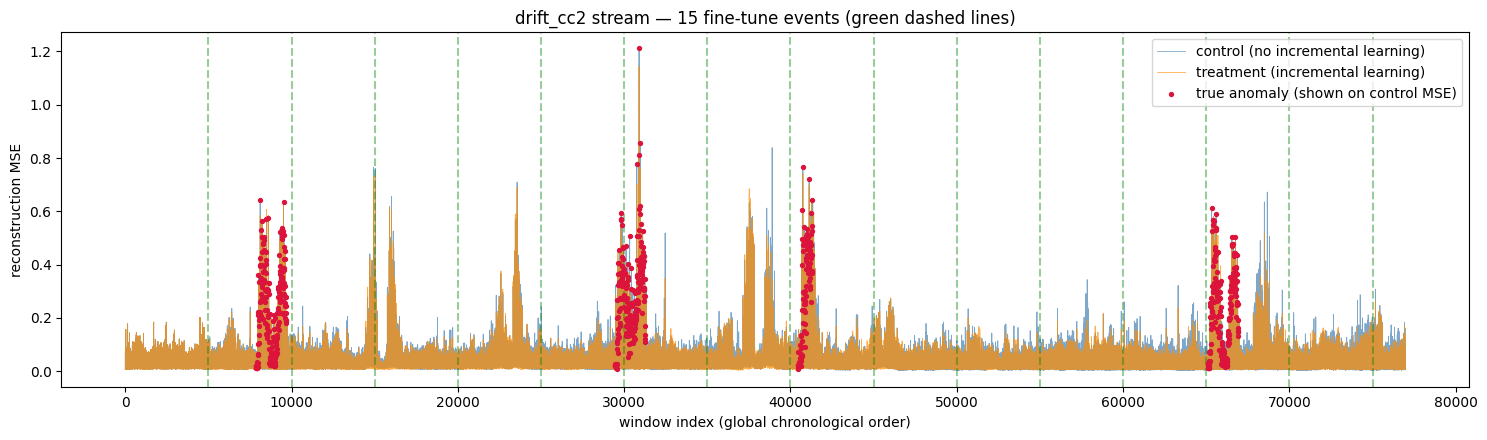

In [8]:
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(mse_control, color='steelblue', lw=0.6, alpha=0.7, label='control (no incremental learning)')
ax.plot(mse_treat, color='darkorange', lw=0.6, alpha=0.7, label='treatment (incremental learning)')
for e in finetune_events:
    ax.axvline(e, color='green', ls='--', alpha=0.4)
anom_idx = np.where(y_stream == 1)[0]
ax.scatter(anom_idx, mse_control[anom_idx], color='crimson', s=8, zorder=5, label='true anomaly (shown on control MSE)')
ax.set_xlabel('window index (global chronological order)'); ax.set_ylabel('reconstruction MSE')
ax.set_title(f'drift_cc2 stream — {len(finetune_events)} fine-tune events (green dashed lines)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'incremental_learning_drift_cc2.png'), dpi=120)
plt.show()

## Step 8 — Save results

In [9]:
save_results = {
    'lightweight_validation': {
        'n_params': n_params, 'file_size_kb': file_size_kb,
        'single_window_latency_ms': single_latency_ms, 'batch_1000_latency_ms': batch_latency_ms,
    },
    'incremental_learning': {
        'refit_interval': REFIT_INTERVAL, 'ft_buffer_size': FT_BUFFER_SIZE, 'ft_lr': FT_LR, 'ft_epochs': FT_EPOCHS,
        'n_finetunes': nft_treat, 'finetune_events': finetune_events,
        'control': result_control, 'treatment': result_treat,
    },
}
out_path = os.path.join(MODEL_DIR, 'incremental_learning_eval.pkl')
with open(out_path, 'wb') as f:
    pickle.dump(save_results, f)
print(f'Saved -> {out_path}')
print()
print('=== RUN THIS NOTEBOOK, THEN SEND BACK: ===')
print('1. Step 1 printout (params / latency / file size)')
print('2. Step 4 printout (how many fine-tune events fired, and at which windows)')
print('3. Step 5 printout (control vs. treatment F1)')
print('4. Step 6 printout (per-fault-type recall comparison)')

Saved -> c:\Users\jthar\Documents\Claude\Projects\module3\models\incremental_learning_eval.pkl

=== RUN THIS NOTEBOOK, THEN SEND BACK: ===
1. Step 1 printout (params / latency / file size)
2. Step 4 printout (how many fine-tune events fired, and at which windows)
3. Step 5 printout (control vs. treatment F1)
4. Step 6 printout (per-fault-type recall comparison)


## What "success" looks like here

- **Step 1** just needs to be reported — there's no pass/fail, it's evidence for
  the "lightweight" claim (expect: tiny parameter count, sub-millisecond
  single-window latency, a model file well under 1MB).
- **Step 4**: if `n_finetunes=0`, the KS-test never triggered — `REFIT_INTERVAL`
  or `KS_ALPHA` likely need loosening (send me the printout either way, this is
  useful information regardless of outcome).
- **Step 5**: if treatment's F1 beats control's, incremental learning is
  earning its place in the pipeline. If it doesn't beat the blended-threshold-only
  result (0.347) — that's still a legitimate, reportable finding, not a failure:
  it would mean the *threshold* adaptation was already capturing most of the
  available gain, and the *model* itself didn't need to change. Either outcome
  answers a real question the proposal asks.